# Predicción de incidentes viales en la Ciudad de Buenos Aires
## Notebook 1 — EDA

**Fuente (Buenos Aires Data):** [Víctimas de siniestros viales](https://data.buenosaires.gob.ar/dataset/victimas-siniestros-viales) — tablas `hechos` y `víctimas`, CABA.


| Parte | Secciones | Qué se hace |
|---|---|---|
| **1 — EDA** | 1 a 9 | se *diagnostica*: estructura, faltantes, duplicados, categóricas, distribuciones, atípicos y coherencia.|

---
# Análisis Exploratorio de Datos

## 1. Carga de los datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setteo los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 60)

In [ ]:
# En Colab hay que montar Drive; si no estamos en Colab, este paso se saltea.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA = "/content/drive/MyDrive/datos/"
except ImportError:
    RUTA = ""          # ejecución local: los CSV están en la misma carpeta del notebook

print("Ruta de los datos:", RUTA if RUTA else "(carpeta actual)")

Mounted at /content/drive
Ruta de los datos: /content/drive/MyDrive/datos/


In [ ]:
# Importo los datos con read_csv
hechos_raw = pd.read_csv(RUTA + "siniestros_viales_hechos.csv",
                         sep=";", encoding="utf-8-sig", low_memory=False)
victimas_raw = pd.read_csv(RUTA + "siniestros_viales_victimas.csv",
                           sep=";", encoding="utf-8-sig", low_memory=False)

# Observo las dimensiones
print("hechos  :", hechos_raw.shape)
print("victimas:", victimas_raw.shape)

hechos  : (65818, 21)
victimas: (75197, 9)


## 2. Conociendo nuestros datasets

¿Cuántas filas y columnas hay?, ¿qué representa cada fila?, ¿qué tipo de dato tiene cada variable?

In [ ]:
hechos_raw.head(3)

,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,rango_horario,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro
0,LC-2019-0000053,1,1,0,0,2019-01-01,2019,1,1,01:55:00,1,NaN,Comuna 8,AUTOPISTA,POINT (101813.84712503915943671 95578.55507230...,-58.44351,-34.669125,AUTO-UTILITARIO,AUTO,UTILITARIO,LEVE
1,LC-2019-0000647,1,0,1,0,2019-01-01,2019,1,1,18:50:00,18,DE LOS CONSTITUYENTES AV. y HABANA,Comuna 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,MOTO,AUTO,GRAVE
2,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,13,NaN,Comuna 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE


In [ ]:
victimas_raw.head(3)

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0022650,2019-01-11,2019.0,BICICLETA,F,25,GRAVE,CICLISTA,NaN
1,LC-2019-0068291,2019-02-01,2019.0,BICICLETA,F,16,GRAVE,CICLISTA,NaN
2,LC-2019-0139186,2019-03-06,2019.0,BICICLETA,F,32,GRAVE,CICLISTA,NaN


In [ ]:
hechos_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65818 entries, 0 to 65817
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id_siniestro                      65818 non-null  object
 1   numero_total_de_victimas          65818 non-null  object
 2   numero_victimas_leve_siniestro    65818 non-null  int64 
 3   numero_victimas_grave_siniestro   65818 non-null  int64 
 4   numero_victimas_mortal_siniestro  65818 non-null  int64 
 5   fecha_siniestro                   65818 non-null  object
 6   anio_siniestro                    65818 non-null  int64 
 7   mes_siniestro                     65818 non-null  int64 
 8   dia_siniestro                     65818 non-null  int64 
 9   hora_siniestro                    65741 non-null  object
 10  rango_horario                     65741 non-null  object
 11  direccion_normalizada_siniestro   52918 non-null  object
 12  comuna_siniestro  

In [ ]:
victimas_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75197 entries, 0 to 75196
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_siniestro                 75193 non-null  object 
 1   fecha_siniestro              75193 non-null  object 
 2   anio_siniestro               75193 non-null  float64
 3   modo_desplazamiento_victima  75193 non-null  object 
 4   sexo_victima                 75193 non-null  object 
 5   edad_victima                 75193 non-null  object 
 6   GRAVEdad_victima             75193 non-null  object 
 7   rol_victima                  75193 non-null  object 
 8   fecha_fallecimiento_victima  703 non-null    object 
dtypes: float64(1), object(8)
memory usage: 5.2+ MB


### Unidad de análisis

| Dataset | Una fila representa | Clave |
|---|---|---|
| `hechos` | un **siniestro vial** ocurrido en la vía pública de CABA | `id_siniestro` |
| `victimas` | una **persona damnificada** en un siniestro | `id_siniestro` (repetido si hubo varias víctimas) |

La relación `hechos` → `victimas` es **uno a muchos**: un mismo `id_siniestro` con varias filas en `victimas` no es un duplicado, es un siniestro con múltiples víctimas.

### Diccionario de variables

**`hechos`**

| Variable | Significado | Tipo conceptual |
|---|---|---|
| `id_siniestro` | Identificador del hecho | Identificador |
| `numero_total_de_victimas` | Víctimas totales | Numérica discreta |
| `numero_victimas_{leve,grave,mortal}_siniestro` | Víctimas por gravedad | Numérica discreta |
| `fecha_siniestro`, `anio_siniestro`, `mes_siniestro`, `dia_siniestro` | Momento | Temporal |
| `hora_siniestro`, `rango_horario` | Hora del hecho | Temporal |
| `direccion_normalizada_siniestro` | Dirección | Texto |
| `comuna_siniestro` | Comuna (1–15) | Categórica ordinal |
| `tipo_de_via_siniestro` | Calle / Avenida / Autopista | Categórica |
| `longitud_siniestro`, `latitud_siniestro`, `geocodificacion_plana` | Ubicación | Numérica / Texto |
| `participantes_siniestro` | Par de modos involucrados | Categórica |
| `modo_desplazamiento_victima` | Modo de la víctima | Categórica |
| `contraparte_siniestro` | Modo de la contraparte | Categórica |
| `gravedad_siniestro` | LEVE / GRAVE / MORTAL | **Categórica ordinal — variable objetivo** |

**`victimas`**

| Variable | Significado | Tipo conceptual |
|---|---|---|
| `id_siniestro` | Hecho al que pertenece | Identificador (FK) |
| `fecha_siniestro`, `anio_siniestro` | Momento | Temporal |
| `modo_desplazamiento_victima` | Modo de la víctima | Categórica |
| `sexo_victima` | Sexo | Categórica |
| `edad_victima` | Edad | Numérica |
| `GRAVEdad_victima` | Gravedad de la lesión | Categórica ordinal |
| `rol_victima` | Conductor / Pasajero / Peatón / Ciclista | Categórica |
| `fecha_fallecimiento_victima` | Fecha de fallecimiento | Temporal (vacío = no falleció) |



## 3. ¿Nuestros datos están completos?

Los faltantes modifican promedios, conteos y gráficos.

In [ ]:
hechos_raw.isnull().sum()

,0
id_siniestro,0
numero_total_de_victimas,0
numero_victimas_leve_siniestro,0
numero_victimas_grave_siniestro,0
numero_victimas_mortal_siniestro,0
fecha_siniestro,0
anio_siniestro,0
mes_siniestro,0
dia_siniestro,0
hora_siniestro,77


In [ ]:
(hechos_raw.isna().mean() * 100).sort_values(ascending=False).round(2)

,0
direccion_normalizada_siniestro,19.60
tipo_de_via_siniestro,18.58
comuna_siniestro,4.58
longitud_siniestro,3.61
latitud_siniestro,3.61
geocodificacion_plana,3.60
hora_siniestro,0.12
rango_horario,0.12
numero_victimas_mortal_siniestro,0.00
id_siniestro,0.00


In [ ]:
victimas_raw.isnull().sum()

,0
id_siniestro,4
fecha_siniestro,4
anio_siniestro,4
modo_desplazamiento_victima,4
sexo_victima,4
edad_victima,4
GRAVEdad_victima,4
rol_victima,4
fecha_fallecimiento_victima,74494


In [ ]:
(victimas_raw.isna().mean() * 100).sort_values(ascending=False).round(2)

,0
fecha_fallecimiento_victima,99.07
id_siniestro,0.01
fecha_siniestro,0.01
modo_desplazamiento_victima,0.01
anio_siniestro,0.01
sexo_victima,0.01
edad_victima,0.01
GRAVEdad_victima,0.01
rol_victima,0.01


Se usa el texto `"SD"` (sin dato) y algunos `"#¡REF!"` en lugar de dejar la celda vacía. Para `isnull()` esos valores están presentes, así que hay que contarlos aparte.

In [ ]:
print("hechos — valores 'SD':")
print((hechos_raw == "SD").sum()[(hechos_raw == "SD").sum() > 0])

print("\nvictimas — valores 'SD':")
print((victimas_raw == "SD").sum()[(victimas_raw == "SD").sum() > 0])

print("\nhechos — valores '#¡REF!':")
print((hechos_raw == "#¡REF!").sum()[(hechos_raw == "#¡REF!").sum() > 0])

hechos — valores 'SD':
numero_total_de_victimas            3276
hora_siniestro                         4
rango_horario                          4
direccion_normalizada_siniestro      727
comuna_siniestro                     535
tipo_de_via_siniestro                315
geocodificacion_plana                  7
longitud_siniestro                   359
latitud_siniestro                    359
modo_desplazamiento_victima        10928
contraparte_siniestro              14066
dtype: int64

victimas — valores 'SD':
modo_desplazamiento_victima    23331
sexo_victima                   17094
edad_victima                   23296
rol_victima                    60127
dtype: int64

hechos — valores '#¡REF!':
longitud_siniestro             1
latitud_siniestro              1
participantes_siniestro        1
modo_desplazamiento_victima    1
contraparte_siniestro          1
dtype: int64


In [ ]:
# Esos textos son la razón por la que columnas numéricas quedaron como texto
print("edad_victima no convertible a número:",
      pd.to_numeric(victimas_raw["edad_victima"], errors="coerce").isna().sum()
      - victimas_raw["edad_victima"].isna().sum())

print("numero_total_de_victimas no convertible:",
      pd.to_numeric(hechos_raw["numero_total_de_victimas"], errors="coerce").isna().sum()
      - hechos_raw["numero_total_de_victimas"].isna().sum())

edad_victima no convertible a número: 23372
numero_total_de_victimas no convertible: 3276


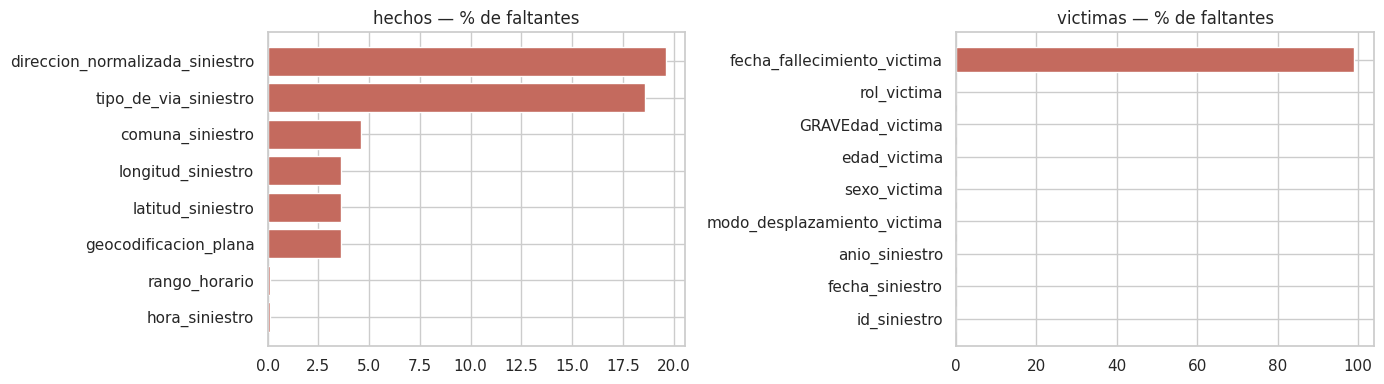

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

faltantes_h = (hechos_raw.isna().mean() * 100).sort_values()
faltantes_h = faltantes_h[faltantes_h > 0]
axes[0].barh(faltantes_h.index, faltantes_h.values, color="#C46A5E")
axes[0].set_title("hechos — % de faltantes")

faltantes_v = (victimas_raw.isna().mean() * 100).sort_values()
faltantes_v = faltantes_v[faltantes_v > 0]
axes[1].barh(faltantes_v.index, faltantes_v.values, color="#C46A5E")
axes[1].set_title("victimas — % de faltantes")

plt.tight_layout()

**Conclusión.** Un faltante no siempre es un problema a rellenar:

- `fecha_fallecimiento_victima` vacía significa que *la víctima no falleció* (no tiene "MORTAL" en "GRAVEdad_victima").
- `direccion_normalizada_siniestro` y las coordenadas vacías podrían ser un fallo de geocodificación.
- `comuna_siniestro` vacía sí es información perdida, se podría hallar con las coordenadas.

## 4. Registros duplicados

Distinguimos dos casos que exigen tratamientos opuestos:

- **duplicado exacto**: la fila completa se repite → puede ser un error de carga;
- **duplicado por clave**: mismo `id_siniestro`, filas distintas → en víctimas, según documentación: son víctimas de un mismo siniestro.

In [ ]:
print("hechos — duplicados exactos     :", hechos_raw.duplicated().sum())
print("hechos — id_siniestro repetido  :", hechos_raw.duplicated(subset=["id_siniestro"]).sum())
print("hechos — id_siniestro únicos    :", hechos_raw["id_siniestro"].nunique())

hechos — duplicados exactos     : 0
hechos — id_siniestro repetido  : 0
hechos — id_siniestro únicos    : 65818


In [ ]:
print("victimas — duplicados exactos   :", victimas_raw.duplicated().sum())
print("victimas — id_siniestro repetido:", victimas_raw.duplicated(subset=["id_siniestro"]).sum())
print("victimas — id_siniestro únicos  :", victimas_raw["id_siniestro"].nunique())

victimas — duplicados exactos   : 1439
victimas — id_siniestro repetido: 9378
victimas — id_siniestro únicos  : 65818


count    65818.00
mean         1.14
std          0.54
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         26.00
dtype: float64

Siniestros con más de una víctima: 6765


<Axes: title={'center': 'Víctimas por siniestro'}>

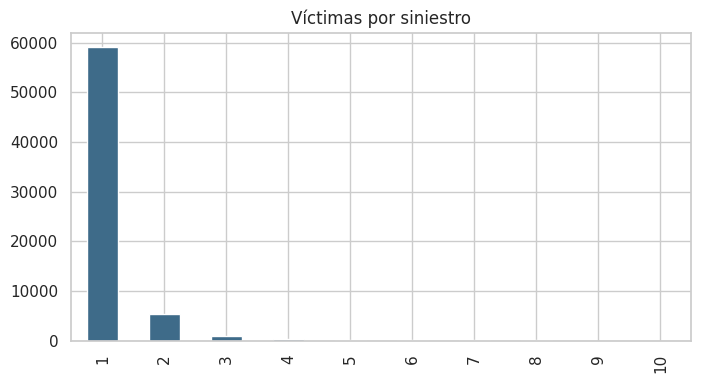

In [ ]:
# ¿Cuántas víctimas tiene un siniestro típico?
victimas_por_siniestro = victimas_raw.groupby("id_siniestro").size()

print(victimas_por_siniestro.describe().round(2))
print("\nSiniestros con más de una víctima:", (victimas_por_siniestro > 1).sum())

victimas_por_siniestro.value_counts().sort_index().head(10).plot(
    kind="bar", color="#3E6B89", title="Víctimas por siniestro")

In [ ]:
# ¿Las filas de victimas coinciden con el total de víctimas declarado en hechos?
total_declarado = pd.to_numeric(hechos_raw["numero_total_de_victimas"], errors="coerce")

print("suma de víctimas declarada en hechos    :", total_declarado.sum())
print("filas en victimas                       :", len(victimas_raw))
print("filas en victimas sin duplicados exactos:", len(victimas_raw.drop_duplicates()))

suma de víctimas declarada en hechos    : 71917.0
filas en victimas                       : 75197
filas en victimas sin duplicados exactos: 73758


In [ ]:
# Integridad referencial hechos <-> victimas
ids_hechos = set(hechos_raw["id_siniestro"])
ids_victimas = set(victimas_raw["id_siniestro"])

print("ids en victimas sin hecho    :", len(ids_victimas - ids_hechos))
print("hechos sin víctima registrada:", len(ids_hechos - ids_victimas))

ids en victimas sin hecho    : 1
hechos sin víctima registrada: 0


> En `victimas`, dos filas idénticas pueden ser **dos personas distintas** con el mismo sexo, edad, rol y gravedad en el mismo siniestro.

## 5. Explorando variables categóricas

Para cada una: ¿cuántas categorías hay?, ¿cuáles predominan?, ¿hay faltantes?, **¿hay categorías escritas de distintas maneras?**

In [ ]:
categoricas_hechos = ["tipo_de_via_siniestro", "modo_desplazamiento_victima",
                      "contraparte_siniestro", "gravedad_siniestro", "comuna_siniestro"]
categoricas_victimas = ["sexo_victima", "GRAVEdad_victima", "rol_victima",
                        "modo_desplazamiento_victima"]

for columna in categoricas_hechos:
    print(f"\n{columna} — {hechos_raw[columna].nunique()} categorías, "
          f"{hechos_raw[columna].isna().sum()} faltantes")
    print(hechos_raw[columna].unique()[:25])


tipo_de_via_siniestro — 5 categorías, 12227 faltantes
['AUTOPISTA' 'AVENIDA' nan 'AV. GRAL. PAZ' 'CALLE' 'SD']

modo_desplazamiento_victima — 14 categorías, 0 faltantes
['AUTO' 'MOTO' 'BICICLETA' 'PEATON' 'SD' 'TAXI' 'CAMION'
 'TRANSPORTE PUBLICO' 'MOVIL' 'MIXTO' 'OTRO' 'UTILITARIO' 'MONOPATIN'
 '#¡REF!']

contraparte_siniestro — 23 categorías, 0 faltantes
['UTILITARIO' 'AUTO' 'CAMION' 'MOVIL' 'TRANSPORTE PUBLICO' 'MOTO' 'SD'
 'TAXI' 'OBJETO FIJO' 'BICICLETA' 'OTRO' 'MULTIPLE' 'PEATON' 'MONOPATIN'
 'TREN' 'auto' 'movil' 'moto' 'camion' 'taxi' 'peaton' 'CAMIONETA'
 '#¡REF!']

gravedad_siniestro — 3 categorías, 0 faltantes
['LEVE' 'GRAVE' 'MORTAL']

comuna_siniestro — 34 categorías, 3017 faltantes
['Comuna 8' 'Comuna 12' 'Comuna 11' 'Comuna 9' 'Comuna 4' 'Comuna 3'
 'Comuna 14' 'Comuna 15' 'Comuna 1' 'Comuna 7' 'Comuna 2' 'Comuna 13'
 'Comuna 5' 'Comuna 6' 'Comuna 10' nan 'COMUNA 1' 'COMUNA 3' 'COMUNA 15'
 'SD' '12' '10' '15' '8' '13']


In [ ]:
for columna in categoricas_victimas:
    print(f"\n{columna} — {victimas_raw[columna].nunique()} categorías, "
          f"{victimas_raw[columna].isna().sum()} faltantes")
    print(victimas_raw[columna].unique()[:25])


sexo_victima — 3 categorías, 4 faltantes
['F' 'M' 'SD' nan]

GRAVEdad_victima — 4 categorías, 4 faltantes
['GRAVE' 'MORTAL' 'LEVE' 'mortal' nan]

rol_victima — 9 categorías, 4 faltantes
['CICLISTA' 'CONDUCTOR' 'conductor' 'PASAJERO' 'PEATON' 'SD' 'Conductor'
 'Pasajero' 'sd' nan]

modo_desplazamiento_victima — 18 categorías, 4 faltantes
['BICICLETA' 'MOTO' 'AUTO' 'TRANSPORTE PUBLICO' 'UTILITARIO' 'PEATON' 'SD'
 'TAXI' 'MOVIL' 'MONOPATIN' 'OTRO' 'CAMION' 'moto' 'auto' 'monopatin'
 'MIXTO' 'camion' 'peaton' nan]


In [ ]:
hechos_raw["gravedad_siniestro"].value_counts(normalize=True).round(4) * 100

,proportion
gravedad_siniestro,
LEVE,94.46
GRAVE,4.49
MORTAL,1.05


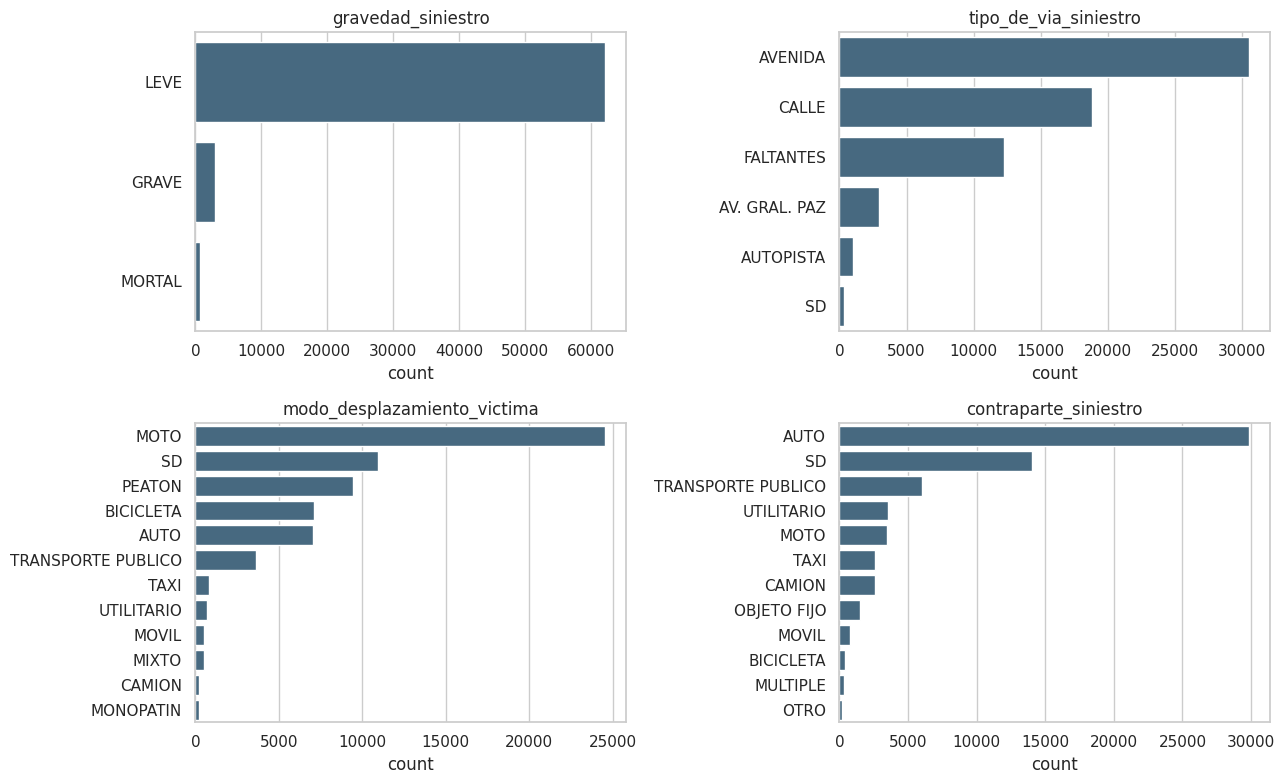

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, columna in zip(axes.ravel(), ["gravedad_siniestro", "tipo_de_via_siniestro",
                                      "modo_desplazamiento_victima", "contraparte_siniestro"]):
    grafico = hechos_raw[columna].fillna("FALTANTES")
    sns.countplot(y=grafico, order=grafico.value_counts().index[:12], ax=ax, color="#3E6B89")
    ax.set_title(columna)
    ax.set_ylabel("")

plt.tight_layout()

### Distribución por comuna

`comuna_siniestro` viene como texto (`"Comuna 8"`, `"COMUNA 3"`, `"12"`, `"SD"`). Para poder graficarla hay que quedarse con el número. Esto es sólo diagnóstico: la conversión definitiva se hace en la sección 12.

comunas no interpretables o faltantes: 3552


<Axes: title={'center': 'Siniestros por comuna'}, xlabel='comuna', ylabel='siniestros'>

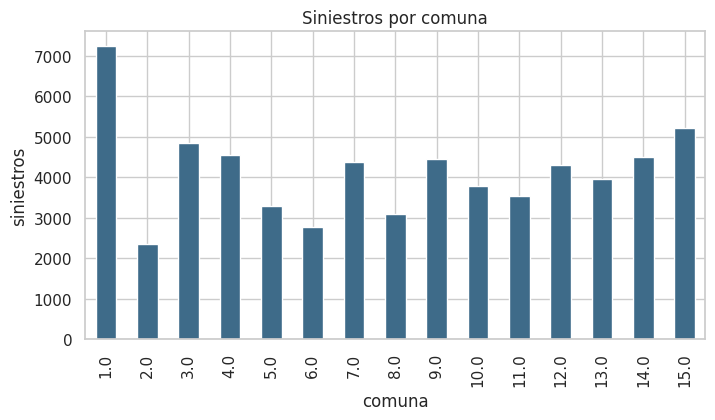

In [ ]:
comuna = hechos_raw["comuna_siniestro"].str.extract(r"(\d+)")[0].astype(float)

print("comunas no interpretables o faltantes:", comuna.isna().sum())

comuna.value_counts().sort_index().plot(
    kind="bar", color="#3E6B89",
    title="Siniestros por comuna", xlabel="comuna", ylabel="siniestros")

In [ ]:
# Siniestros distintos por comuna y año
pd.crosstab(comuna, hechos_raw["anio_siniestro"])

anio_siniestro,2019,2020,2021,2022,2023,2024,2025
0,,,,,,,
1.0,1109,632,816,1015,1137,1132,1400
2.0,404,196,288,336,337,374,415
3.0,708,467,561,712,766,783,861
4.0,721,460,575,668,675,621,842
5.0,504,333,401,431,467,483,666
6.0,418,250,297,462,403,425,517
7.0,636,412,487,638,653,711,831
8.0,481,255,347,471,455,471,608
9.0,718,417,565,609,670,674,797


## 6. El mismo dato escrito de distintas maneras

Este es el hallazgo central del diagnóstico categórico. Contamos cuántas categorías **colapsan** al normalizar (quitar espacios → mayúsculas → sin acentos). La diferencia entre el conteo crudo y el normalizado son categorías artificiales: no son fenómenos distintos, son tipeos distintos.

In [ ]:
for columna in ["tipo_de_via_siniestro", "modo_desplazamiento_victima",
                "contraparte_siniestro", "gravedad_siniestro"]:
    normalizada = (hechos_raw[columna].str.strip().str.upper()
                   .str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii"))
    print(f"{columna:32s} crudas: {hechos_raw[columna].nunique():3d}   "
          f"normalizadas: {normalizada.nunique():3d}   "
          f"colapsadas: {hechos_raw[columna].nunique() - normalizada.nunique():3d}")

tipo_de_via_siniestro            crudas:   5   normalizadas:   5   colapsadas:   0
modo_desplazamiento_victima      crudas:  14   normalizadas:  14   colapsadas:   0
contraparte_siniestro            crudas:  23   normalizadas:  17   colapsadas:   6
gravedad_siniestro               crudas:   3   normalizadas:   3   colapsadas:   0


In [ ]:
for columna in ["sexo_victima", "GRAVEdad_victima", "rol_victima", "modo_desplazamiento_victima"]:
    normalizada = (victimas_raw[columna].str.strip().str.upper()
                   .str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii"))
    print(f"{columna:32s} crudas: {victimas_raw[columna].nunique():3d}   "
          f"normalizadas: {normalizada.nunique():3d}   "
          f"colapsadas: {victimas_raw[columna].nunique() - normalizada.nunique():3d}")

sexo_victima                     crudas:   3   normalizadas:   3   colapsadas:   0
GRAVEdad_victima                 crudas:   4   normalizadas:   3   colapsadas:   1
rol_victima                      crudas:   9   normalizadas:   5   colapsadas:   4
modo_desplazamiento_victima      crudas:  18   normalizadas:  13   colapsadas:   5


In [ ]:
# Qué variantes concretas colapsan en una misma categoría
normalizada = (victimas_raw["rol_victima"].str.strip().str.upper()
               .str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii"))

pd.crosstab(normalizada, victimas_raw["rol_victima"])

rol_victima,CICLISTA,CONDUCTOR,Conductor,PASAJERO,PEATON,Pasajero,SD,conductor,sd
rol_victima,,,,,,,,,
CICLISTA,6281,0,0,0,0,0,0,0,0
CONDUCTOR,0,220,43,0,0,0,0,44,0
PASAJERO,0,0,0,60,0,4,0,0,0
PEATON,0,0,0,0,8405,0,0,0,0
SD,0,0,0,0,0,0,60127,0,9


Además de la normalización tipográfica hacen falta **diccionarios de equivalencias semánticas**, que ninguna función automática puede resolver: `AUTO-UTILITARIO` y `UTILITARIO` son el mismo modo; `BUS` y `OMNIBUS` son `COLECTIVO`; `MOTOCICLETA` y `CICLOMOTOR` son `MOTO`.

El criterio para la Parte 2: **reducir categorías artificiales sin borrar diferencias reales.** Unificar `CAMIONETA` con `AUTO` es defendible (masa y protección similares); unificar `MOTO` con `AUTO` no lo es.

## 7. Distribución de la edad de las víctimas

¿Cuál es la media y la mediana?, ¿el mínimo y el máximo?, ¿es simétrica?, ¿hay valores imposibles?

In [ ]:
edad = pd.to_numeric(victimas_raw["edad_victima"], errors="coerce")

print("media    :", edad.mean().round(2))
print("mediana  :", edad.median())
print("asimetría:", edad.skew().round(3))
edad.describe().round(2)

media    : 37.94
mediana  : 35.0
asimetría: 0.755


,edad_victima
count,51821.00
mean,37.94
std,15.82
min,0.00
25%,26.00
50%,35.00
75%,47.00
max,116.00


In [ ]:
print("edades imposibles (> 115):", (edad >= 115).sum())
print("edades imposibles (< 0)  :", (edad < 0).sum())

victimas_raw[edad > 115].head()

edades imposibles (> 115): 1
edades imposibles (< 0)  : 0


,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
19213,LC-2025-0400556,2025-5-27,2025.0,MOTO,F,116,LEVE,SD,NaN


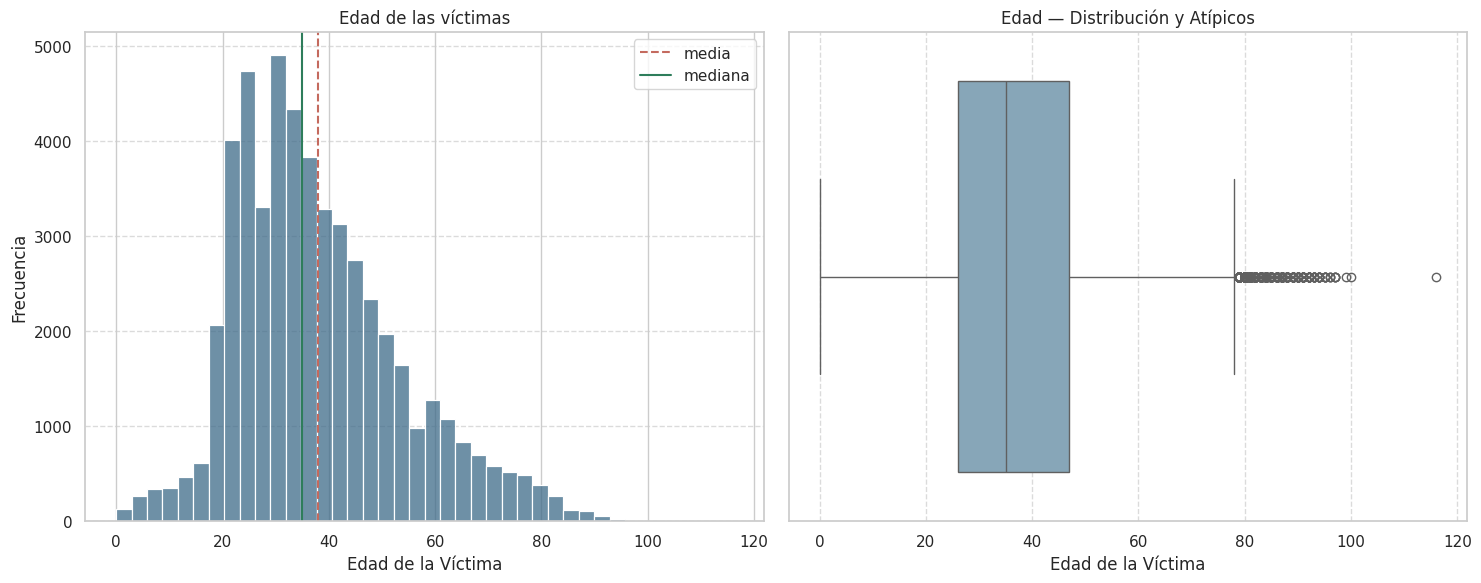

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Increased figure size for better readability

sns.histplot(edad, bins=40, ax=axes[0], color="#3E6B89")
axes[0].axvline(edad.mean(), color="#C46A5E", linestyle="--", label="media")
axes[0].axvline(edad.median(), color="#2E7D5B", label="mediana")
axes[0].legend()
axes[0].set_title("Edad de las víctimas")
axes[0].set_xlabel("Edad de la Víctima") # Added x-label
axes[0].set_ylabel("Frecuencia") # Added y-label
axes[0].grid(axis='y', linestyle='--', alpha=0.7) # Added grid

sns.boxplot(x=edad, ax=axes[1], color="#7FA8C0", orient='h') # Set orientation to horizontal for better spread
axes[1].set_title("Edad — Distribución y Atípicos") # More descriptive title
axes[1].set_xlabel("Edad de la Víctima") # Added x-label
axes[1].set_ylabel("") # Removed y-label for horizontal boxplot
axes[1].grid(axis='x', linestyle='--', alpha=0.7) # Added grid

plt.tight_layout() # Ensure elements do not overlap
plt.show() # Explicitly show the plot

**Lectura.** La distribución es **asimétrica positiva** (cola larga hacia las edades altas) y la media queda por encima de la mediana. Para imputar, la mediana es la medida robusta; la media se desplazaría por los extremos.

Las edades por encima de 115 no son atípicos: son **errores**. En Argentina la persona más longeva detectada se llamaba Casilda Benegas y llegó a los 115 años.

## 8. Valores atípicos en las variables numéricas

Un valor atípico no siempre es un error. La pregunta no es "¿lo elimino?" sino **"¿es posible y tiene sentido dentro del problema?"**

In [ ]:
numericas = ["numero_total_de_victimas", "numero_victimas_leve_siniestro",
             "numero_victimas_grave_siniestro", "numero_victimas_mortal_siniestro"]

# Estas columnas traen textos como "SD": hay que convertirlas para poder analizarlas.
hechos_numericas = hechos_raw[numericas].apply(pd.to_numeric, errors="coerce")

print("valores no numéricos por columna:")
print(hechos_numericas.isna().sum() - hechos_raw[numericas].isna().sum())

hechos_numericas.describe().round(2)

valores no numéricos por columna:
numero_total_de_victimas            3276
numero_victimas_leve_siniestro         0
numero_victimas_grave_siniestro        0
numero_victimas_mortal_siniestro       0
dtype: int64


,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro
count,62542.00,65818.00,65818.00,65818.00
mean,1.15,1.08,0.05,0.01
std,0.55,0.58,0.23,0.10
min,1.00,0.00,0.00,0.00
25%,1.00,1.00,0.00,0.00
50%,1.00,1.00,0.00,0.00
75%,1.00,1.00,0.00,0.00
max,26.00,26.00,10.00,2.00


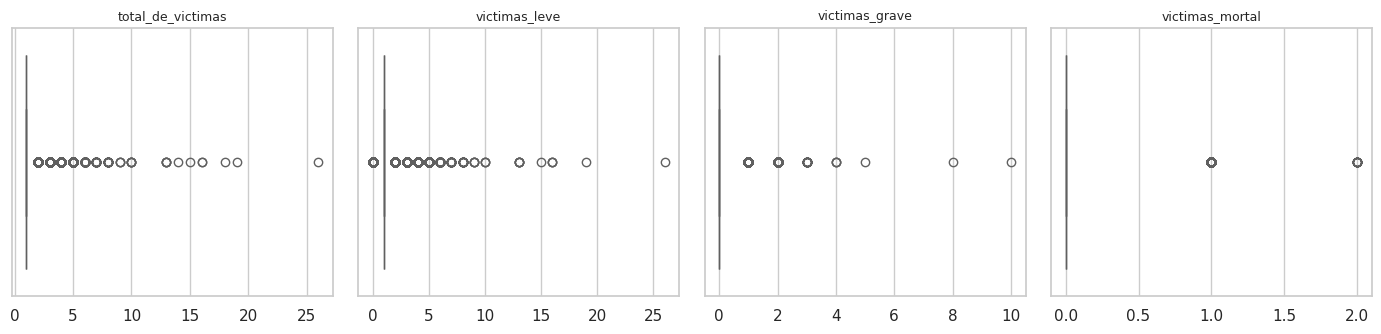

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, columna in zip(axes, numericas):
    sns.boxplot(x=hechos_numericas[columna], ax=ax, color="#7FA8C0")
    ax.set_title(columna.replace("numero_", "").replace("_siniestro", ""), fontsize=9)
    ax.set_xlabel("")

plt.tight_layout()

In [ ]:
# Bigote superior: Q3 + 1.5 * IQR
q1 = hechos_numericas["numero_total_de_victimas"].quantile(0.25)
q3 = hechos_numericas["numero_total_de_victimas"].quantile(0.75)
bigote_superior = q3 + 1.5 * (q3 - q1)

print("bigote superior:", bigote_superior)
print("siniestros por encima del bigote:",
      (hechos_numericas["numero_total_de_victimas"] > bigote_superior).sum())

bigote superior: 1.0
siniestros por encima del bigote: 6766


coordenadas fuera de CABA: 0
coordenadas faltantes    : 3031


Text(0.5, 1.0, 'Siniestros geolocalizados')

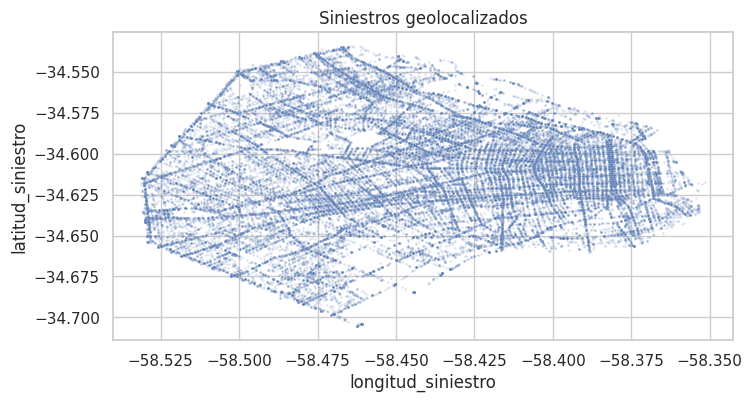

In [ ]:
# Coordenadas: ¿hay puntos fuera de CABA? (límites aproximados de la Ciudad)
latitud = pd.to_numeric(hechos_raw["latitud_siniestro"], errors="coerce")
longitud = pd.to_numeric(hechos_raw["longitud_siniestro"], errors="coerce")

fuera_de_caba = ((~latitud.between(-34.71, -34.52) | ~longitud.between(-58.54, -58.33))
                 & latitud.notna())

print("coordenadas fuera de CABA:", fuera_de_caba.sum())
print("coordenadas faltantes    :", latitud.isna().sum())

sns.scatterplot(x=longitud[~fuera_de_caba], y=latitud[~fuera_de_caba], s=3, alpha=0.2)
plt.title("Siniestros geolocalizados")

In [ ]:
# Hora: ¿valores fuera de 0-23?
hora = pd.to_datetime(hechos_raw["hora_siniestro"], errors="coerce", format="mixed").dt.hour

print("horas no interpretables:", hora.isna().sum() - hechos_raw["hora_siniestro"].isna().sum())
print("horas fuera de 0-23    :", (~hora.between(0, 23)).sum() - hora.isna().sum())

horas no interpretables: 4
horas fuera de 0-23    : 0


**Criterio adoptado** (se decide acá, se ejecuta en la sección 14)

| Caso | Diagnóstico | Acción |
|---|---|---|
| `numero_total_de_victimas` alto | siniestro múltiple, poco frecuente pero **real** | se marca con un flag, **no se elimina** |
| `edad_victima` > 110 | **imposible** | → faltante, luego imputación por mediana |
| `hora` fuera de 0–23 | **imposible** | → faltante |
| `comuna` fuera de 1–15 | **imposible** | → faltante |
| coordenadas fuera de CABA | error de **geocodificación** | → faltante |

El flag `flag_atipico_victimas` permite después analizar los datos con y sin esos casos sin haber perdido información.

## 9. Coherencia interna

Un dato puede estar presente y aun así ser incorrecto. En `hechos`, la suma de víctimas por gravedad debe igualar el total. Y la gravedad declarada en `gravedad_siniestro` debe ser coherente con los conteos.

In [ ]:
suma_por_gravedad = hechos_numericas[["numero_victimas_leve_siniestro",
                                      "numero_victimas_grave_siniestro",
                                      "numero_victimas_mortal_siniestro"]].sum(axis=1)

incoherentes = suma_por_gravedad != hechos_numericas["numero_total_de_victimas"]

print("filas donde leve + grave + mortal != total:", incoherentes.sum())
print("porcentaje:", round(incoherentes.mean() * 100, 2), "%")

filas donde leve + grave + mortal != total: 3278
porcentaje: 4.98 %


In [ ]:
# Gravedad derivada de los conteos: MORTAL si hubo muertos, GRAVE si hubo graves, si no LEVE
gravedad_derivada = pd.Series("LEVE", index=hechos_raw.index)
gravedad_derivada[hechos_numericas["numero_victimas_grave_siniestro"] > 0] = "GRAVE"
gravedad_derivada[hechos_numericas["numero_victimas_mortal_siniestro"] > 0] = "MORTAL"

gravedad_declarada = hechos_raw["gravedad_siniestro"].str.strip().str.upper()

print("discrepancias declarada vs. derivada:", (gravedad_declarada != gravedad_derivada).sum())

pd.crosstab(gravedad_declarada.fillna("FALTANTE"), gravedad_derivada)

discrepancias declarada vs. derivada: 31


col_0,GRAVE,LEVE,MORTAL
gravedad_siniestro,,,
GRAVE,2955,0,0
LEVE,31,62143,0
MORTAL,0,0,689


In [ ]:
# Otra regla verificable: quien tiene fecha de fallecimiento debería figurar como MORTAL
fallecio = victimas_raw["fecha_fallecimiento_victima"].notna()
dice_mortal = victimas_raw["GRAVEdad_victima"].str.strip().str.upper() == "MORTAL"

print("con fecha de fallecimiento pero gravedad != MORTAL:", (fallecio & ~dice_mortal).sum())
print("MORTAL sin fecha de fallecimiento                 :", (~fallecio & dice_mortal).sum())

con fecha de fallecimiento pero gravedad != MORTAL: 0
MORTAL sin fecha de fallecimiento                 : 0
